In [1]:
import torch
from gsnn.models.GSNN import GSNN
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from gsnn_mds.data.AMLDataset import AMLDataset

import seaborn as sbn 
from pypath.utils import mapping

%load_ext autoreload
%autoreload 2 


/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/pypath/inputs/ramp/_rest.py:54: UserWarning: Failed to load RaMP ID types.
  warnings.warn(msg)


In [2]:
EXP_ID = 'default_002'

In [3]:
def create_input_mapping(inputs_df, data):
    """Create mapping from patient IDs to input vectors.
    
    Note: inputs_df is ordered identically to data.node_names_dict['input']
    and can be directly converted into the input tensor.
    """
    print("Creating input mapping...")
    
    id2x = {}
    
    # Verify that inputs_df columns match the input node names
    input_nodes = data.node_names_dict['input']
    
    # Reorder inputs_df columns to match the order of input nodes
    inputs_df_ordered = inputs_df[input_nodes]
    
    # Convert each row to input tensor directly
    for sample_id, row in inputs_df_ordered.iterrows():
        x = torch.tensor(row.values.astype(np.float32), dtype=torch.float32)
        id2x[sample_id] = x
    
    print(f"Created input mapping for {len(id2x)} patients")
    return id2x

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torch.load(f'../../workflow_outputs/gsnn-mds/exp/{EXP_ID}/gsnn/gsnn_model.pt', weights_only=False, map_location=device)

data = torch.load(f'../../workflow_outputs/gsnn-mds/exp/{EXP_ID}/graph/graph.pt', weights_only=False)

inputs_df = pd.read_csv(f'../../workflow_outputs/gsnn-mds/exp/{EXP_ID}/graph/inputs.csv')
inputs_df = inputs_df[lambda x: x.id.str.startswith('M')] # MLL-XXX or MUC-xxx

id2x = create_input_mapping(inputs_df.set_index('id'), data)
ids = list(id2x.keys()) 

drug_inputs = [x.split('__')[1] for x in data.node_names_dict['input'] if x.split('__')[0] == 'DRUG']


Creating input mapping...
Created input mapping for 683 patients


In [5]:
inhibitors = [x.split('__')[1] for x in data.node_names_dict['input'] if x.split('__')[0] == 'DRUG']
inhibitors.pop(-1) # remove none 

'pd173955'

In [6]:
response = 0

synth = {'id': [], 'partition': [], 'response': [], 'inhibitor': [], 'inhibitor_1': [], 'inhibitor_2': []}
for drug1 in inhibitors: 
    for drug2 in (inhibitors + [None]): 
        for id in ids: 

            if drug2 is None: 
                inhibitor = drug1
            else: 
                inhibitor = drug1 + ' + ' + drug2

            synth['id'].append(id)
            synth['partition'].append('infer')
            synth['response'].append(response)
            synth['inhibitor'].append(inhibitor)
            synth['inhibitor_1'].append(drug1)
            synth['inhibitor_2'].append(drug2)

synth = pd.DataFrame(synth)
synth.head() 

,id,partition,response,inhibitor,inhibitor_1,inhibitor_2
0,MLL_00003,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449)
1,MLL_00009,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449)
2,MLL_09939,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449)
3,MLL_09941,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449)
4,MLL_09942,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449)


In [7]:
pred_dataset = AMLDataset(id2x, synth, data.node_names_dict['input'])
pred_loader = torch.utils.data.DataLoader(pred_dataset, batch_size=512, shuffle=False, num_workers=20) 

print(f'Number of predictions: {len(pred_dataset)}')

Number of predictions: 9753240


In [8]:
yhat = [] 

with torch.inference_mode(): 
    for i, (x, _) in enumerate(pred_loader):
        print(f'progress: {i}/{len(pred_loader)}', end='\r')
        yhat.append(model(x.to(device)).detach().cpu()) 

yhat = torch.cat(yhat, axis=0).detach().cpu().numpy()

yhat = yhat.reshape(-1) 

synth_drug = synth.assign(yhat = yhat) 
synth_drug.head() 

,id,partition,response,inhibitor,inhibitor_1,inhibitor_2,yhat
0,MLL_00003,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449),1.649699
1,MLL_00009,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449),1.332070
2,MLL_09939,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449),1.583967
3,MLL_09941,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449),1.515607
4,MLL_09942,infer,0,vismodegib (gdc-0449) + vismodegib (gdc-0449),vismodegib (gdc-0449),vismodegib (gdc-0449),1.324555


In [9]:
synth_drug[['id', 'inhibitor_1', 'inhibitor_2', 'yhat']].to_csv(f'mds_predictions_{EXP_ID}.csv', index=False)

In [10]:
synth_drug.tail()

,id,partition,response,inhibitor,inhibitor_1,inhibitor_2,yhat
9753235,MUC_00663,infer,0,vandetanib (zd6474),vandetanib (zd6474),None,1.027053
9753236,MUC_00670,infer,0,vandetanib (zd6474),vandetanib (zd6474),None,0.986087
9753237,MUC_00680,infer,0,vandetanib (zd6474),vandetanib (zd6474),None,0.774555
9753238,MUC_00707,infer,0,vandetanib (zd6474),vandetanib (zd6474),None,0.969122
9753239,MUC_00722,infer,0,vandetanib (zd6474),vandetanib (zd6474),None,0.731654


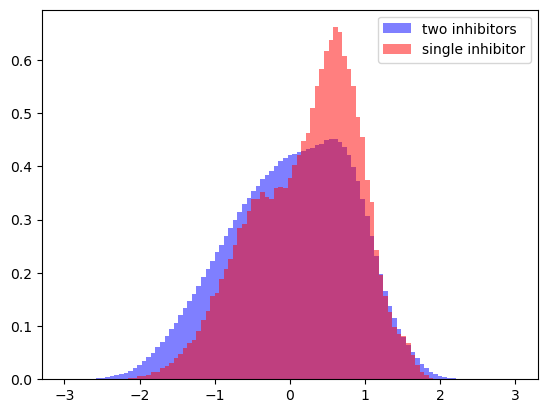

In [11]:
_bins = np.linspace(-3, 3, 100)

plt.figure() 
plt.hist(synth_drug[lambda x: ~x.inhibitor_2.isna()]['yhat'], bins=_bins, color='b', alpha=0.5, label='two inhibitors', density=True) 
plt.hist(synth_drug[lambda x: x.inhibitor_2.isna()]['yhat'], bins=_bins, color='r', alpha=0.5, label='single inhibitor', density=True) 
plt.legend()
plt.show() 
